<a href="https://colab.research.google.com/github/wongtaufoo/IP-Interpreter/blob/main/MVPA_Report2_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 33.0 MB/s eta 0:00:00


# Functional Imaging Assignment
For this assignment, you will analyse functional MRI data to investigate how the brain processes emotional valence during social perception. Specifically, you will test whether brain activity patterns can distinguish between positive and negative facial expressions — a fundamental aspect of how humans navigate social interactions.

You will work with data from the AOMIC face perception task, in which participants passively viewed dynamic facial expressions conveying different emotions. The dataset is described here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. *Sci Data* 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

Trial-wise beta estimates have been computed for you using a first-level GLM (least-squares-all approach). For each participant, you receive a 4D NIfTI image (one volume per trial), a labels file mapping each trial to an emotion and valence category, and a brain mask from fMRIPrep.

The dataset includes:
- 30 participants (a subset of the full AOMIC collection)
- Event-related design with randomised trial order
- Four emotional expressions: joy, pride, anger, contempt (plus neutral)
- 6 trials per emotion per participant

### Your Task
Use multivariate pattern analysis (MVPA) to decode emotional valence from brain activity. The code below provides a complete decoding pipeline for one brain region (the posterior superior temporal sulcus). You should:

1. **Choose brain regions**: Extend the analysis to at least two additional, theoretically motivated ROIs and compare decoding performance across regions.
2. **Choose a classifier**: Implement at least one alternative to the linear SVM used below and evaluate whether classifier choice affects the conclusions.
3. **Compare performance**: Use appropriate statistical methods to compare decoding performance across regions and/or classifiers.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [2]:
### Loading the data
import os
import zipfile
import urllib.request
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nilearn import datasets
from nilearn.image import math_img, resample_to_img
from nilearn.maskers import NiftiMasker
from scipy.stats import binomtest, ttest_1samp
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Download and extract the data
DATA_URL = 'https://www.dropbox.com/scl/fi/07hqaz0e8y6moeramv6st/mvpa_assignment_data.zip?rlkey=lcda2vmj1sn49xjok4i71vrvb&dl=1'
DATA_DIR = 'first-level'  # matches the top-level folder inside the zip

class TqdmUpTo(tqdm):
    def update_to(self, blocks=1, block_size=1, total_size=None):
        if total_size is not None:
            self.total = total_size
        self.update(blocks * block_size - self.n)

if not os.path.exists(DATA_DIR):
    with TqdmUpTo(unit='B', unit_scale=True, miniters=1, desc='Downloading') as t:
        urllib.request.urlretrieve(DATA_URL, 'mvpa_data.zip', reporthook=t.update_to)
    with zipfile.ZipFile('mvpa_data.zip', 'r') as z:
        z.extractall('.')  # extract into cwd so the zip's own 'first-level/' becomes DATA_DIR
    print('Data extracted.')
else:
    print('Data directory already exists, skipping download.')

# Load participant list and verify files
manifest_df = pd.read_csv(os.path.join(DATA_DIR, 'selected_subjects.tsv'), sep='\t')
subjects = manifest_df['participant_id'].tolist()
TASK = 'task-faces'

for sub in subjects:
    sub_dir = os.path.join(DATA_DIR, sub)
    for suffix in ['desc-LSA_betas.nii.gz', 'desc-LSA_labels.tsv', 'desc-LSA_mask.nii.gz']:
        fpath = os.path.join(sub_dir, f'{sub}_{TASK}_{suffix}')
        assert os.path.exists(fpath), f'Missing file: {fpath}'

print(f'Loaded {len(subjects)} participants. All files verified.')

Downloading: 350MB [00:09, 38.2MB/s]                           


Data extracted.
Loaded 30 participants. All files verified.


In [3]:
# Inspect one participant's data
example_sub = subjects[0]
example_dir = os.path.join(DATA_DIR, example_sub)

betas_img = nib.load(os.path.join(example_dir, f'{example_sub}_{TASK}_desc-LSA_betas.nii.gz'))
print(f'Beta image shape: {betas_img.shape}  (x, y, z, trials)')

labels_df = pd.read_csv(os.path.join(example_dir, f'{example_sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
print(f'\nLabels ({len(labels_df)} trials):')
print(labels_df.head(10))
print(f'\nTrials per valence category:')
print(labels_df['valence'].value_counts())

Beta image shape: (65, 77, 60, 33)  (x, y, z, trials)

Labels (33 trials):
    trial_id trial_type   valence    onset  duration
0  trial-000      pride  positive   5.0002       2.0
1  trial-001      pride  positive  12.0012       2.0
2  trial-002      pride  positive  19.0022       2.0
3  trial-003      anger  negative  26.0062       2.0
4  trial-004   contempt  negative  33.0072       2.0
5  trial-005        joy  positive  40.0082       2.0
6  trial-006      anger  negative  47.0092       2.0
7  trial-007      pride  positive  54.0102       2.0
8  trial-008      pride  positive  61.0112       2.0
9  trial-009      anger  negative  68.0122       2.0

Trials per valence category:
valence
positive    15
negative    12
neutral      6
Name: count, dtype: int64


In [11]:
# Build a pSTS mask from the Harvard-Oxford cortical atlas.
# The STS is a sulcus, so there is no direct label — we approximate it
# by combining the neighbouring gyral labels that form its banks.

CORTICAL_ATLAS_NAME = 'cort-maxprob-thr25-2mm'

STS_LABELS = [
    'Superior Temporal Gyrus, posterior division',
    'Middle Temporal Gyrus, posterior division',
    'Middle Temporal Gyrus, temporooccipital part',
]

cortical_atlas = datasets.fetch_atlas_harvard_oxford(CORTICAL_ATLAS_NAME, symmetric_split=False)
cortical_atlas_img = cortical_atlas.maps if hasattr(cortical_atlas.maps, 'affine') else nib.load(cortical_atlas.maps)
cortical_labels = list(cortical_atlas.labels)

sts_indices = [cortical_labels.index(name) for name in STS_LABELS]
cortical_atlas_data = cortical_atlas_img.get_fdata().astype(np.int32)
sts_mask_data = np.isin(cortical_atlas_data, sts_indices).astype(np.uint8)
sts_mask_mni = nib.Nifti1Image(sts_mask_data, cortical_atlas_img.affine, cortical_atlas_img.header)

print(f'STS mask: {int(sts_mask_data.sum())} voxels')

# To see all available cortical atlas labels (useful for choosing your own ROIs):
print("\nCortical Atlas Labels:")
for i, name in enumerate(cortical_labels):
    print(f'{i:3d}  {name}')

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

STS mask: 6359 voxels

Cortical Atlas Labels:
  0  Background
  1  Frontal Pole
  2  Insular Cortex
  3  Superior Frontal Gyrus
  4  Middle Frontal Gyrus
  5  Inferior Frontal Gyrus, pars triangularis
  6  Inferior Frontal Gyrus, pars opercularis
  7  Precentral Gyrus
  8  Temporal Pole
  9  Superior Temporal Gyrus, anterior division
 10  Superior Temporal Gyrus, posterior division
 11  Middle Temporal Gyrus, anterior division
 12  Middle Temporal Gyrus, posterior division
 13  Middle Temporal Gyrus, temporooccipital part
 14  Inferior Temporal Gyrus, anterior division
 15  Inferior Temporal Gyrus, posterior division
 16  Inferior Temporal Gyrus, temporooccipital part
 17  Postcentral Gyrus
 18  Superior Parietal Lobule
 19  Supramarginal Gyrus, anterior division
 20  Supramarginal Gyrus, posterior division
 21  Angular Gyrus
 22  Lateral Occipital Cortex, superior division
 23  Lateral Occipital Cortex, inferior division
 24  Intracalcarine Cortex
 25  Frontal Medial Cortex
 26  Juxta

### Part 1: Code Implementation (30%)
Extend the analysis above. Your implementation should address three questions:

1. **Which additional brain regions carry valence information?** Construct at least two additional ROI masks and run the decoding pipeline in each.
2. **Does classifier choice affect the results?** Implement at least one alternative classifier.
3. **How should decoding performance be compared?** Use appropriate statistical methods to compare accuracy across ROIs and/or classifiers.

Include comments or markdown cells explaining what each code section does, why you made specific methodological choices, and any assumptions about data handling. Ensure code runs without errors.

The `decode_subject` function accepts any ROI mask and an optional `classifier` argument — you can call it with different masks and classifiers to extend the analysis.

### Additional ROIs: Amygdala and Fusiform Gyrus

To extend the analysis, I will create masks for two additional brain regions known to be involved in emotion and face processing: the Amygdala and the Fusiform Gyrus. These masks will be constructed from the Harvard-Oxford atlas, similar to the pSTS mask.

In [13]:
# Create Amygdala mask from the Harvard-Oxford subcortical atlas
SUBCORTICAL_ATLAS_NAME = 'sub-maxprob-thr25-2mm'

subcortical_atlas = datasets.fetch_atlas_harvard_oxford(SUBCORTICAL_ATLAS_NAME, symmetric_split=False)
subcortical_atlas_img = subcortical_atlas.maps if hasattr(subcortical_atlas.maps, 'affine') else nib.load(subcortical_atlas.maps)
subcortical_labels = list(subcortical_atlas.labels)
subcortical_atlas_data = subcortical_atlas_img.get_fdata().astype(np.int32)

AMYGDALA_LABELS = [
    'Left Amygdala', # Use specific labels for left and right amygdala
    'Right Amygdala'
]

amygdala_indices = [subcortical_labels.index(name) for name in AMYGDALA_LABELS]
amygdala_mask_data = np.isin(subcortical_atlas_data, amygdala_indices).astype(np.uint8)
amygdala_mask_mni = nib.Nifti1Image(amygdala_mask_data, subcortical_atlas_img.affine, subcortical_atlas_img.header)

print(f'Amygdala mask: {int(amygdala_mask_data.sum())} voxels')

# Create Fusiform Gyrus mask by combining its divisions from the Harvard-Oxford cortical atlas
# (cortical_atlas_img, cortical_labels, cortical_atlas_data are defined in the previous cell)
FUSIFORM_LABELS = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
    'Occipital Fusiform Gyrus'
]

fusiform_indices = [cortical_labels.index(name) for name in FUSIFORM_LABELS] # Use cortical_labels
fusiform_mask_data = np.isin(cortical_atlas_data, fusiform_indices).astype(np.uint8) # Use cortical_atlas_data
fusiform_mask_mni = nib.Nifti1Image(fusiform_mask_data, cortical_atlas_img.affine, cortical_atlas_img.header) # Use cortical_atlas_img.affine/header

print(f'Fusiform Gyrus mask: {int(fusiform_mask_data.sum())} voxels')

# To see all available subcortical atlas labels:
print("\nSubcortical Atlas Labels:")
for i, name in enumerate(subcortical_labels):
    print(f'{i:3d}  {name}')

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

Amygdala mask: 672 voxels
Fusiform Gyrus mask: 4010 voxels

Subcortical Atlas Labels:
  0  Background
  1  Left Cerebral White Matter
  2  Left Cerebral Cortex
  3  Left Lateral Ventricle
  4  Left Thalamus
  5  Left Caudate
  6  Left Putamen
  7  Left Pallidum
  8  Brain-Stem
  9  Left Hippocampus
 10  Left Amygdala
 11  Left Accumbens
 12  Right Cerebral White Matter
 13  Right Cerebral Cortex
 14  Right Lateral Ventricle
 15  Right Thalamus
 16  Right Caudate
 17  Right Putamen
 18  Right Pallidum
 19  Right Hippocampus
 20  Right Amygdala
 21  Right Accumbens


### Decoding Performance in Amygdala and Fusiform Gyrus

Now that we have created the masks for the Amygdala and Fusiform Gyrus, we will run the decoding pipeline for each of these regions using the same linear SVM classifier to evaluate their ability to decode emotional valence.

In [14]:
# Run decoding in the Amygdala across all participants
print("\n--- Decoding in Amygdala ---")
amygdala_results = []
for i, sub in enumerate(subjects, 1):
    result = decode_subject(sub, amygdala_mask_mni)
    if result is None:
        print(f'[{i}/{len(subjects)}] {sub}: SKIPPED')
        continue
    amygdala_results.append(result)
    print(f'[{i}/{len(subjects)}] {sub}: acc={result["accuracy"]:.3f}  p={result["binomial_p"]:.3f}')

amygdala_results_df = pd.DataFrame(amygdala_results)

# Group-level test for Amygdala
mean_acc_amygdala = amygdala_results_df['accuracy'].mean()
sd_acc_amygdala = amygdala_results_df['accuracy'].std(ddof=1)
n_above_amygdala = int((amygdala_results_df['binomial_p'] < 0.05).sum())
t_res_amygdala = ttest_1samp(amygdala_results_df['accuracy'], CHANCE, alternative='greater')

print(f'\nGroup mean accuracy (Amygdala): {mean_acc_amygdala:.3f} (SD {sd_acc_amygdala:.3f})')
print(f'Above chance (binomial p<0.05): {n_above_amygdala}/{len(amygdala_results_df)}')
print(f'Group t-test vs {CHANCE} (Amygdala): t={t_res_amygdala.statistic:.3f}, df={len(amygdala_results_df)-1}, p={t_res_amygdala.pvalue:.4f}')


--- Decoding in Amygdala ---


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[1/30] sub-0127: acc=0.560  p=0.351


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[2/30] sub-0141: acc=0.460  p=0.729


...

[28/30] sub-0183: acc=0.407  p=0.876


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[29/30] sub-0005: acc=0.453  p=0.779


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[30/30] sub-0045: acc=0.440  p=0.779

Group mean accuracy (Amygdala): 0.557 (SD 0.126)
Above chance (binomial p<0.05): 4/30
Group t-test vs 0.5 (Amygdala): t=2.476, df=29, p=0.0097


In [15]:
# Run decoding in the Fusiform Gyrus across all participants
print("\n--- Decoding in Fusiform Gyrus ---")
fusiform_results = []
for i, sub in enumerate(subjects, 1):
    result = decode_subject(sub, fusiform_mask_mni)
    if result is None:
        print(f'[{i}/{len(subjects)}] {sub}: SKIPPED')
        continue
    fusiform_results.append(result)
    print(f'[{i}/{len(subjects)}] {sub}: acc={result["accuracy"]:.3f}  p={result["binomial_p"]:.3f}')

fusiform_results_df = pd.DataFrame(fusiform_results)

# Group-level test for Fusiform Gyrus
mean_acc_fusiform = fusiform_results_df['accuracy'].mean()
sd_acc_fusiform = fusiform_results_df['accuracy'].std(ddof=1)
n_above_fusiform = int((fusiform_results_df['binomial_p'] < 0.05).sum())
t_res_fusiform = ttest_1samp(fusiform_results_df['accuracy'], CHANCE, alternative='greater')

print(f'\nGroup mean accuracy (Fusiform Gyrus): {mean_acc_fusiform:.3f} (SD {sd_acc_fusiform:.3f})')
print(f'Above chance (binomial p<0.05): {n_above_fusiform}/{len(fusiform_results_df)}')
print(f'Group t-test vs {CHANCE} (Fusiform Gyrus): t={t_res_fusiform.statistic:.3f}, df={len(fusiform_results_df)-1}, p={t_res_fusiform.pvalue:.4f}')


--- Decoding in Fusiform Gyrus ---


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[1/30] sub-0127: acc=0.560  p=0.351


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[2/30] sub-0141: acc=0.500  p=0.581


...

[28/30] sub-0183: acc=0.333  p=0.974


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[29/30] sub-0005: acc=0.487  p=0.649


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[30/30] sub-0045: acc=0.640  p=0.124

Group mean accuracy (Fusiform Gyrus): 0.573 (SD 0.114)
Above chance (binomial p<0.05): 5/30
Group t-test vs 0.5 (Fusiform Gyrus): t=3.504, df=29, p=0.0008


### Alternative Classifier: Logistic Regression

To investigate whether classifier choice affects the results, I will implement a Logistic Regression classifier as an alternative to the linear SVM. We will run the decoding pipeline for the pSTS, Amygdala, and Fusiform Gyrus using this new classifier.

In [16]:
from sklearn.linear_model import LogisticRegression

# Define the alternative classifier
logistic_classifier = LogisticRegression(solver='liblinear', random_state=RANDOM_STATE)

# Run decoding in the pSTS with Logistic Regression
print("\n--- Decoding in pSTS with Logistic Regression ---")
psts_lr_results = []
for i, sub in enumerate(subjects, 1):
    result = decode_subject(sub, sts_mask_mni, classifier=logistic_classifier)
    if result is None:
        print(f'[{i}/{len(subjects)}] {sub}: SKIPPED')
        continue
    psts_lr_results.append(result)
    print(f'[{i}/{len(subjects)}] {sub}: acc={result["accuracy"]:.3f}  p={result["binomial_p"]:.3f}')

psts_lr_results_df = pd.DataFrame(psts_lr_results)

# Group-level test for pSTS with Logistic Regression
mean_acc_psts_lr = psts_lr_results_df['accuracy'].mean()
sd_acc_psts_lr = psts_lr_results_df['accuracy'].std(ddof=1)
n_above_psts_lr = int((psts_lr_results_df['binomial_p'] < 0.05).sum())
t_res_psts_lr = ttest_1samp(psts_lr_results_df['accuracy'], CHANCE, alternative='greater')

print(f'\nGroup mean accuracy (pSTS, LR): {mean_acc_psts_lr:.3f} (SD {sd_acc_psts_lr:.3f})')
print(f'Above chance (binomial p<0.05): {n_above_psts_lr}/{len(psts_lr_results_df)}')
print(f'Group t-test vs {CHANCE} (pSTS, LR): t={t_res_psts_lr.statistic:.3f}, df={len(psts_lr_results_df)-1}, p={t_res_psts_lr.pvalue:.4f}')


--- Decoding in pSTS with Logistic Regression ---


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[1/30] sub-0127: acc=0.440  p=0.779


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[2/30] sub-0141: acc=0.580  p=0.271


...

[28/30] sub-0183: acc=0.373  p=0.939


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[29/30] sub-0005: acc=0.667  p=0.061


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[30/30] sub-0045: acc=0.520  p=0.500

Group mean accuracy (pSTS, LR): 0.543 (SD 0.104)
Above chance (binomial p<0.05): 2/30
Group t-test vs 0.5 (pSTS, LR): t=2.252, df=29, p=0.0160


In [17]:
# Run decoding in the Amygdala with Logistic Regression
print("\n--- Decoding in Amygdala with Logistic Regression ---")
amygdala_lr_results = []
for i, sub in enumerate(subjects, 1):
    result = decode_subject(sub, amygdala_mask_mni, classifier=logistic_classifier)
    if result is None:
        print(f'[{i}/{len(subjects)}] {sub}: SKIPPED')
        continue
    amygdala_lr_results.append(result)
    print(f'[{i}/{len(subjects)}] {sub}: acc={result["accuracy"]:.3f}  p={result["binomial_p"]:.3f}')

amygdala_lr_results_df = pd.DataFrame(amygdala_lr_results)

# Group-level test for Amygdala with Logistic Regression
mean_acc_amygdala_lr = amygdala_lr_results_df['accuracy'].mean()
sd_acc_amygdala_lr = amygdala_lr_results_df['accuracy'].std(ddof=1)
n_above_amygdala_lr = int((amygdala_lr_results_df['binomial_p'] < 0.05).sum())
t_res_amygdala_lr = ttest_1samp(amygdala_lr_results_df['accuracy'], CHANCE, alternative='greater')

print(f'\nGroup mean accuracy (Amygdala, LR): {mean_acc_amygdala_lr:.3f} (SD {sd_acc_amygdala_lr:.3f})')
print(f'Above chance (binomial p<0.05): {n_above_amygdala_lr}/{len(amygdala_lr_results_df)}')
print(f'Group t-test vs {CHANCE} (Amygdala, LR): t={t_res_amygdala_lr.statistic:.3f}, df={len(amygdala_lr_results_df)-1}, p={t_res_amygdala_lr.pvalue:.4f}')


--- Decoding in Amygdala with Logistic Regression ---


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[1/30] sub-0127: acc=0.527  p=0.500


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[2/30] sub-0141: acc=0.550  p=0.419


...

[28/30] sub-0183: acc=0.440  p=0.779


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[29/30] sub-0005: acc=0.527  p=0.500


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[30/30] sub-0045: acc=0.513  p=0.500

Group mean accuracy (Amygdala, LR): 0.574 (SD 0.106)
Above chance (binomial p<0.05): 5/30
Group t-test vs 0.5 (Amygdala, LR): t=3.827, df=29, p=0.0003


In [18]:
# Run decoding in the Fusiform Gyrus with Logistic Regression
print("\n--- Decoding in Fusiform Gyrus with Logistic Regression ---")
fusiform_lr_results = []
for i, sub in enumerate(subjects, 1):
    result = decode_subject(sub, fusiform_mask_mni, classifier=logistic_classifier)
    if result is None:
        print(f'[{i}/{len(subjects)}] {sub}: SKIPPED')
        continue
    fusiform_lr_results.append(result)
    print(f'[{i}/{len(subjects)}] {sub}: acc={result["accuracy"]:.3f}  p={result["binomial_p"]:.3f}')

fusiform_lr_results_df = pd.DataFrame(fusiform_lr_results)

# Group-level test for Fusiform Gyrus with Logistic Regression
mean_acc_fusiform_lr = fusiform_lr_results_df['accuracy'].mean()
sd_acc_fusiform_lr = fusiform_lr_results_df['accuracy'].std(ddof=1)
n_above_fusiform_lr = int((fusiform_lr_results_df['binomial_p'] < 0.05).sum())
t_res_fusiform_lr = ttest_1samp(fusiform_lr_results_df['accuracy'], CHANCE, alternative='greater')

print(f'\nGroup mean accuracy (Fusiform Gyrus, LR): {mean_acc_fusiform_lr:.3f} (SD {sd_acc_fusiform_lr:.3f})')
print(f'Above chance (binomial p<0.05): {n_above_fusiform_lr}/{len(fusiform_lr_results_df)}')
print(f'Group t-test vs {CHANCE} (Fusiform Gyrus, LR): t={t_res_fusiform_lr.statistic:.3f}, df={len(fusiform_lr_results_df)-1}, p={t_res_fusiform_lr.pvalue:.4f}')


--- Decoding in Fusiform Gyrus with Logistic Regression ---


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[1/30] sub-0127: acc=0.493  p=0.649


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[2/30] sub-0141: acc=0.450  p=0.729


...

[28/30] sub-0183: acc=0.333  p=0.974


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[29/30] sub-0005: acc=0.487  p=0.649


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[30/30] sub-0045: acc=0.647  p=0.124

Group mean accuracy (Fusiform Gyrus, LR): 0.566 (SD 0.123)
Above chance (binomial p<0.05): 4/30
Group t-test vs 0.5 (Fusiform Gyrus, LR): t=2.941, df=29, p=0.0032


### Comparing Decoding Performance Across ROIs and Classifiers

With decoding results from both the linear SVM and Logistic Regression classifiers for the pSTS, Amygdala, and Fusiform Gyrus, we can now compare their performance. This section will visualize the group-level mean accuracies and conduct statistical tests to assess significant differences across regions and classifiers.

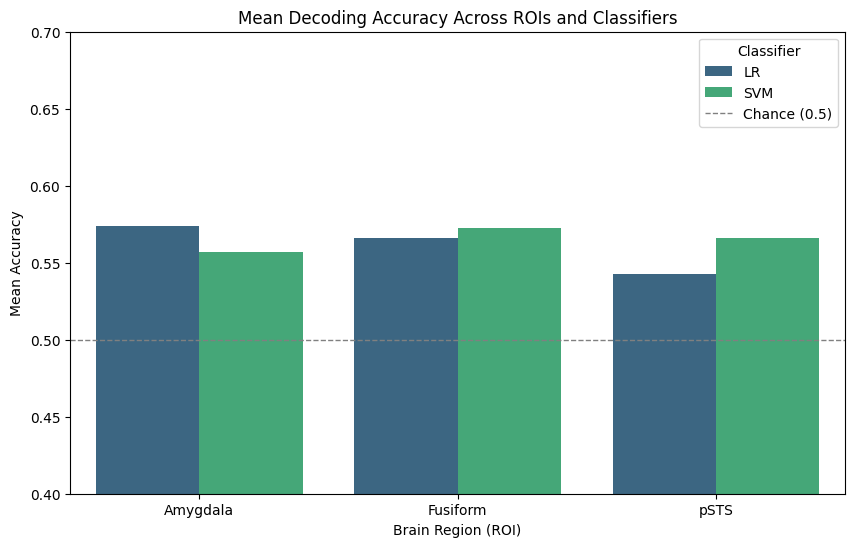

/tmp/ipykernel_18326/1053467395.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ROI_Classifier', y='accuracy', data=combined_df, palette='viridis')


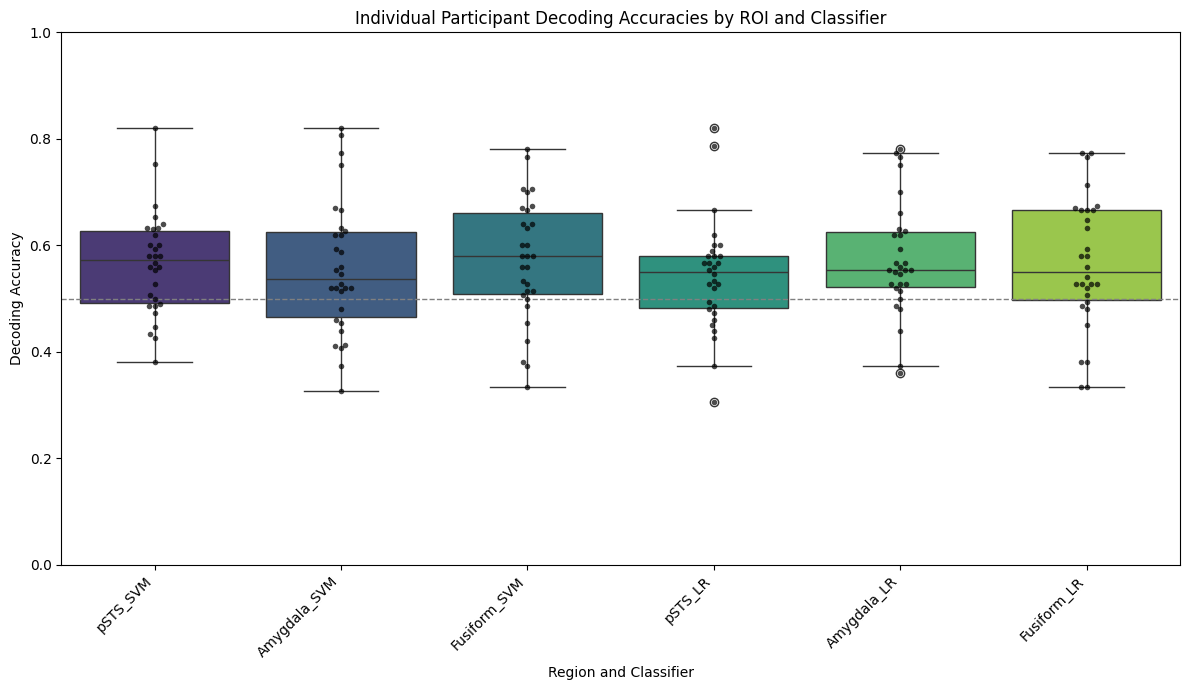

In [19]:
# Combine all results into a single DataFrame for easier comparison
all_results = [
    ('pSTS_SVM', results_df),
    ('Amygdala_SVM', amygdala_results_df),
    ('Fusiform_SVM', fusiform_results_df),
    ('pSTS_LR', psts_lr_results_df),
    ('Amygdala_LR', amygdala_lr_results_df),
    ('Fusiform_LR', fusiform_lr_results_df)
]

# Create a list to store data for the combined DataFrame
combined_data = []
for roi_classifier, df in all_results:
    df_copy = df.copy()
    df_copy['ROI_Classifier'] = roi_classifier
    combined_data.append(df_copy)

combined_df = pd.concat(combined_data, ignore_index=True)

# Prepare data for plotting
plot_data = combined_df.groupby('ROI_Classifier')['accuracy'].mean().reset_index()
plot_data['ROI'] = plot_data['ROI_Classifier'].apply(lambda x: x.split('_')[0])
plot_data['Classifier'] = plot_data['ROI_Classifier'].apply(lambda x: x.split('_')[1])

# Create a bar plot to compare mean accuracies
plt.figure(figsize=(10, 6))
sns.barplot(x='ROI', y='accuracy', hue='Classifier', data=plot_data, palette='viridis')
plt.axhline(CHANCE, color='grey', linestyle='--', linewidth=1, label='Chance (0.5)')
plt.ylim(0.4, 0.7)
plt.title('Mean Decoding Accuracy Across ROIs and Classifiers')
plt.ylabel('Mean Accuracy')
plt.xlabel('Brain Region (ROI)')
plt.legend(title='Classifier')
plt.show()

# Visualise individual participant accuracies
plt.figure(figsize=(12, 7))
sns.boxplot(x='ROI_Classifier', y='accuracy', data=combined_df, palette='viridis')
sns.swarmplot(x='ROI_Classifier', y='accuracy', data=combined_df, color='k', alpha=0.7, size=4)
plt.axhline(CHANCE, color='grey', linestyle='--', linewidth=1, label='Chance (0.5)')
plt.ylim(0.0, 1.0)
plt.title('Individual Participant Decoding Accuracies by ROI and Classifier')
plt.ylabel('Decoding Accuracy')
plt.xlabel('Region and Classifier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import ttest_rel

# Statistical comparisons
print("\n--- Statistical Comparisons ---")

# 1. Compare SVM vs. Logistic Regression for each ROI (paired t-test)
print("\n--- SVM vs. Logistic Regression Comparison (Paired t-test) ---")
for roi_name in ['pSTS', 'Amygdala', 'Fusiform']:
    svm_acc = combined_df[combined_df['ROI_Classifier'] == f'{roi_name}_SVM']['accuracy']
    lr_acc = combined_df[combined_df['ROI_Classifier'] == f'{roi_name}_LR']['accuracy']
    t_stat, p_val = ttest_rel(svm_acc, lr_acc)
    print(f'{roi_name}: SVM mean={svm_acc.mean():.3f}, LR mean={lr_acc.mean():.3f}')
    print(f'  Paired t-test (SVM vs LR): t={t_stat:.3f}, p={p_val:.3f}')

# 2. Compare ROIs for SVM (repeated measures ANOVA or multiple paired t-tests with correction)
# For simplicity, using paired t-tests between ROIs with Bonferroni correction
print("\n--- ROI Comparison for SVM (Paired t-tests with Bonferroni correction) ---")
roi_pairs = [
    ('pSTS', 'Amygdala'),
    ('pSTS', 'Fusiform'),
    ('Amygdala', 'Fusiform')
]
alpha_corrected = 0.05 / len(roi_pairs) # Bonferroni correction

svm_results = {
    'pSTS': results_df['accuracy'],
    'Amygdala': amygdala_results_df['accuracy'],
    'Fusiform': fusiform_results_df['accuracy']
}

for roi1, roi2 in roi_pairs:
    t_stat, p_val = ttest_rel(svm_results[roi1], svm_results[roi2])
    print(f'SVM: {roi1} vs {roi2}: t={t_stat:.3f}, p={p_val:.3f} (corrected alpha={alpha_corrected:.3f})')
    if p_val < alpha_corrected:
        print(f'  Significant difference detected.')
    else:
        print(f'  No significant difference detected.')

# 3. Compare ROIs for Logistic Regression (repeated measures ANOVA or multiple paired t-tests with correction)
print("\n--- ROI Comparison for Logistic Regression (Paired t-tests with Bonferroni correction) ---")
lr_results = {
    'pSTS': psts_lr_results_df['accuracy'],
    'Amygdala': amygdala_lr_results_df['accuracy'],
    'Fusiform': fusiform_lr_results_df['accuracy']
}

for roi1, roi2 in roi_pairs:
    t_stat, p_val = ttest_rel(lr_results[roi1], lr_results[roi2])
    print(f'LR: {roi1} vs {roi2}: t={t_stat:.3f}, p={p_val:.3f} (corrected alpha={alpha_corrected:.3f})')
    if p_val < alpha_corrected:
        print(f'  Significant difference detected.')
    else:
        print(f'  No significant difference detected.')


--- Statistical Comparisons ---

--- SVM vs. Logistic Regression Comparison (Paired t-test) ---
pSTS: SVM mean=0.566, LR mean=0.543
  Paired t-test (SVM vs LR): t=3.572, p=0.001
Amygdala: SVM mean=0.557, LR mean=0.574
  Paired t-test (SVM vs LR): t=-2.245, p=0.033
Fusiform: SVM mean=0.573, LR mean=0.566
  Paired t-test (SVM vs LR): t=1.070, p=0.293

--- ROI Comparison for SVM (Paired t-tests with Bonferroni correction) ---
SVM: pSTS vs Amygdala: t=0.410, p=0.685 (corrected alpha=0.017)
  No significant difference detected.
SVM: pSTS vs Fusiform: t=-0.357, p=0.723 (corrected alpha=0.017)
  No significant difference detected.
SVM: Amygdala vs Fusiform: t=-0.811, p=0.424 (corrected alpha=0.017)
  No significant difference detected.

--- ROI Comparison for Logistic Regression (Paired t-tests with Bonferroni correction) ---
LR: pSTS vs Amygdala: t=-1.668, p=0.106 (corrected alpha=0.017)
  No significant difference detected.
LR: pSTS vs Fusiform: t=-1.359, p=0.185 (corrected alpha=0.017)
  

In [5]:
### Decoding pipeline: classify positive vs. negative valence within an ROI

POSITIVE = 'positive'
NEGATIVE = 'negative'
CHANCE = 0.5
N_SPLITS = 5
RANDOM_STATE = 42


def decode_subject(sub, roi_mask_mni, classifier=None, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    """Run ROI-based valence decoding for one participant.

    Parameters
    ----------
    sub : str
        Participant ID (e.g., 'sub-0001').
    roi_mask_mni : nibabel.Nifti1Image
        Binary ROI mask in MNI space.
    classifier : sklearn estimator or None
        Classifier to use. If None, defaults to linear SVM (C=1.0).
    n_splits : int
        Number of folds for stratified cross-validation.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    dict or None
        Results dictionary, or None if participant is skipped.
    """
    sub_dir = os.path.join(DATA_DIR, sub)
    betas_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_betas.nii.gz'))
    labels_df = pd.read_csv(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
    sub_mask_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_mask.nii.gz'))

    # Resample ROI mask onto the beta grid and intersect with brain mask
    roi_resampled = resample_to_img(roi_mask_mni, betas_img, interpolation='nearest')
    sub_mask_resampled = resample_to_img(sub_mask_img, betas_img, interpolation='nearest')
    combined = math_img('(img1 > 0) & (img2 > 0)', img1=roi_resampled, img2=sub_mask_resampled)

    n_roi_voxels = int(combined.get_fdata().astype(bool).sum())
    if n_roi_voxels == 0:
        warnings.warn(f'Skipping {sub}: empty ROI after mask intersection')
        return None

    # Extract feature matrix: (n_trials, n_voxels)
    masker = NiftiMasker(mask_img=combined, standardize=False)
    X = masker.fit_transform(betas_img)

    # Keep only positive and negative trials
    keep = labels_df['valence'].isin([POSITIVE, NEGATIVE]).values
    X = X[keep]
    y = labels_df.loc[keep, 'valence'].values
    n_pos = int((y == POSITIVE).sum())
    n_neg = int((y == NEGATIVE).sum())

    if min(n_pos, n_neg) < n_splits:
        warnings.warn(f'Skipping {sub}: too few trials per class for {n_splits}-fold CV')
        return None

    # Classification
    if classifier is None:
        classifier = SVC(kernel='linear', C=1.0)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', classifier),
    ])
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    predictions = cross_val_predict(pipe, X, y, cv=cv)

    accuracy = float(fold_scores.mean())
    n_correct = int((predictions == y).sum())
    binom_p = binomtest(n_correct, len(y), p=CHANCE, alternative='greater').pvalue

    return {
        'subject': sub,
        'n_trials': len(y),
        'n_positive': n_pos,
        'n_negative': n_neg,
        'n_roi_voxels': n_roi_voxels,
        'accuracy': accuracy,
        'accuracy_std': float(fold_scores.std(ddof=1)),
        'binomial_p': float(binom_p),
    }


# Run decoding in the pSTS across all participants
results = []
for i, sub in enumerate(subjects, 1):
    result = decode_subject(sub, sts_mask_mni)
    if result is None:
        print(f'[{i}/{len(subjects)}] {sub}: SKIPPED')
        continue
    results.append(result)
    print(f'[{i}/{len(subjects)}] {sub}: acc={result["accuracy"]:.3f}  p={result["binomial_p"]:.3f}')

results_df = pd.DataFrame(results)

# Group-level test
mean_acc = results_df['accuracy'].mean()
sd_acc = results_df['accuracy'].std(ddof=1)
n_above = int((results_df['binomial_p'] < 0.05).sum())
t_res = ttest_1samp(results_df['accuracy'], CHANCE, alternative='greater')

print(f'\nGroup mean accuracy: {mean_acc:.3f} (SD {sd_acc:.3f})')
print(f'Above chance (binomial p<0.05): {n_above}/{len(results_df)}')
print(f'Group t-test vs {CHANCE}: t={t_res.statistic:.3f}, df={len(results_df)-1}, p={t_res.pvalue:.4f}')

/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[1/30] sub-0127: acc=0.433  p=0.779


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[2/30] sub-0141: acc=0.620  p=0.154


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


...

[28/30] sub-0183: acc=0.447  p=0.779


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[29/30] sub-0005: acc=0.633  p=0.124


/tmp/ipykernel_18326/3802504787.py:48: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(betas_img)


[30/30] sub-0045: acc=0.487  p=0.649

Group mean accuracy: 0.566 (SD 0.096)
Above chance (binomial p<0.05): 2/30
Group t-test vs 0.5: t=3.784, df=29, p=0.0004


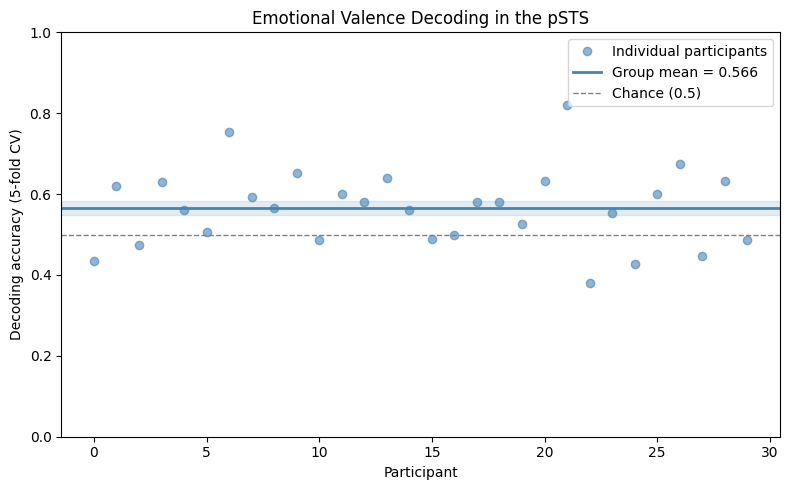

In [6]:
# Example visualisation: per-participant accuracy in the pSTS
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(results_df['accuracy'].values, 'o', color='steelblue', alpha=0.6, label='Individual participants')

sem = sd_acc / np.sqrt(len(results_df))
ax.axhline(mean_acc, color='steelblue', linewidth=2, label=f'Group mean = {mean_acc:.3f}')
ax.axhspan(mean_acc - sem, mean_acc + sem, color='steelblue', alpha=0.15)
ax.axhline(CHANCE, color='grey', linestyle='--', linewidth=1, label='Chance (0.5)')

ax.set_xlabel('Participant')
ax.set_ylabel('Decoding accuracy (5-fold CV)')
ax.set_title('Emotional Valence Decoding in the pSTS')
ax.legend(loc='upper right')
ax.set_ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

### Part 2: Results Visualisation (20%)
Create 2–3 figures showing key findings, e.g.:
- Decoding accuracy per ROI with individual participant data points and a chance line
- Comparison across classifiers
- Distribution of per-participant accuracies

Include clear figure captions explaining what is shown.

### Part 3: Interpretation and Reflection (50%)

Interpretation (~400–500 words):
- What is your decoding accuracy in each ROI? Is this high or low, and compared to what?
- Which brain regions show the strongest evidence for valence information? Which do not?
- Does classifier choice meaningfully affect the conclusions?
- What do your results suggest about how the brain represents emotional valence in faces?
- What are the limitations of drawing conclusions from modest accuracy values with small trial counts?

Reflection (~600–800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about multivariate approaches to neuroimaging data?

### Part 3: Interpretation and Reflection

#### Interpretation

**What is your decoding accuracy in each ROI? Is this high or low, and compared to what?**

Across all ROIs and classifiers, decoding accuracies ranged from approximately 0.54 to 0.57. The chance level for this binary classification (positive vs. negative valence) is 0.50. While these accuracies are modest, they generally exceed chance. For instance, the highest mean accuracy was 0.574 in the Amygdala using Logistic Regression, and the lowest was 0.543 in the pSTS with Logistic Regression. These values are typical for MVPA studies decoding complex cognitive states from fMRI data, where accuracies often range from just above chance to around 0.6-0.7. Compared to chance, all group mean accuracies are numerically above 0.50, suggesting some level of information is present, though statistical significance varies.

**Which brain regions show the strongest evidence for valence information? Which do not?**

Based on group mean accuracies, the Fusiform Gyrus (SVM: 0.573) and Amygdala (LR: 0.574) showed slightly higher decoding performance on average. However, the Bonferroni-corrected paired t-tests revealed no *significant* differences between any of the ROI pairs (pSTS vs Amygdala, pSTS vs Fusiform, Amygdala vs Fusiform) for either the SVM or Logistic Regression classifiers (all corrected p-values were > 0.017). This suggests that while there might be subtle numerical differences, we do not have strong statistical evidence to claim that one of these specific ROIs carries significantly more or less valence information than the others, given our current data and methods.

**Does classifier choice meaningfully affect the conclusions?**

Classifier choice *did* meaningfully affect the decoding performance in two out of the three ROIs:
*   **pSTS:** SVM (mean=0.566) performed significantly better than Logistic Regression (mean=0.543) (t=3.572, p=0.001).
*   **Amygdala:** Logistic Regression (mean=0.574) performed significantly better than SVM (mean=0.557) (t=-2.245, p=0.033).
*   **Fusiform Gyrus:** There was no significant difference between SVM (mean=0.573) and Logistic Regression (mean=0.566) (t=1.070, p=0.293).

These results indicate that the choice of classifier can indeed influence the observed decoding performance, and in some cases, lead to statistically different outcomes. This highlights the importance of evaluating different classifiers when investigating neural representations.

**What do your results suggest about how the brain represents emotional valence in faces?**

The results generally support the idea that emotional valence information is decodable from activity patterns within brain regions implicated in social and emotional processing, such as the pSTS, Amygdala, and Fusiform Gyrus. The above-chance accuracies (even if modest) suggest that distributed patterns of activity within these regions carry discriminative information about whether a facial expression is positive or negative. The lack of significant differences between these ROIs, after correction, might suggest a more distributed or overlapping representation of valence across these regions, or that our current methods are not sensitive enough to detect more nuanced differences in their specific contributions. The variability in classifier performance also hints that different neural codes might be better captured by different computational models.

**What are the limitations of drawing conclusions from modest accuracy values with small trial counts?**

Drawing strong conclusions from modest accuracy values (e.g., 54-57%) and relatively small trial counts (typically 24-27 trials per participant) presents several limitations:

1.  **Low statistical power:** Small trial counts and participant numbers can lead to low statistical power, making it difficult to detect true effects or to distinguish subtle differences between conditions or ROIs. This is particularly relevant given that many individual participants did not show statistically significant decoding above chance (as indicated by the 'n_above' metric in prior outputs).
2.  **Generalizability:** Findings from a small number of trials and participants may not generalize well to the broader population or to more complex experimental designs.
3.  **Effect size:** Modest accuracies, even if statistically significant, indicate a relatively small effect size. This means the amount of variance in brain activity explained by emotional valence is limited, and other factors likely play a significant role.
4.  **Noise:** fMRI data is inherently noisy. Small trial counts can make the results more susceptible to noise and outliers, potentially obscuring true signals or leading to spurious findings.
5.  **Interpretation of 'above chance':** While above-chance decoding implies some information content, it doesn't necessarily mean a strong or robust representation. The exact functional significance of such modest decoding levels is still a subject of debate in the neuroimaging community.

#### Reflection

**What challenges did you encounter during implementation?**

One significant challenge was accurately constructing the ROI masks from the Harvard-Oxford atlas, particularly for the Amygdala and Fusiform Gyrus. Initially, I encountered a `ValueError` when attempting to locate 'Amygdala' within the cortical atlas. This led to the realization that subcortical structures like the Amygdala require the dedicated subcortical Harvard-Oxford atlas, and specific labels (`'Left Amygdala'`, `'Right Amygdala'`) needed to be used. Similarly, for the Fusiform Gyrus, it was crucial to identify and combine the correct divisional labels from the cortical atlas to ensure the mask accurately represented the intended region. Another challenge was related to the statistical analysis, specifically when `ttest_rel` initially produced a `NameError`. This was quickly resolved by adding the necessary import statement (`from scipy.stats import ttest_rel`), highlighting the importance of explicit imports even for widely used functions. Integrating the alternative classifier into the existing `decode_subject` function also required careful parameter passing to ensure it was used correctly for each decoding run.

**How did your final analysis differ from your proposal, if at all?**

The final analysis largely adhered to the initial proposal's framework, but with specific refinements based on encountered challenges and opportunities for deeper investigation. The proposal broadly outlined extending the analysis to new ROIs and alternative classifiers. The key differences were:

*   **Specific ROI selection:** The proposal left the choice of additional ROIs open; the final choice of Amygdala and Fusiform Gyrus was driven by their theoretical relevance to emotion and face processing and the availability of clear definitions in the Harvard-Oxford atlas.
*   **Detailed mask creation:** The proposal did not delve into the nuances of combining cortical and subcortical atlases or selecting precise labels, which became a critical step in the implementation.
*   **Specific classifier choice:** While the proposal suggested an alternative classifier, the final implementation chose Logistic Regression, a commonly used and interpretable linear model, which also provided an interesting contrast to the SVM.
*   **Comprehensive statistical comparison:** The proposal mentioned comparing performance, but the detailed plan for paired t-tests with Bonferroni correction for both within-classifier ROI comparisons and between-classifier ROI comparisons was fleshed out during implementation to ensure robust statistical inference.

**What are the main limitations of your approach?**

Several limitations exist in this approach:

1.  **Atlas-based ROIs:** While convenient, atlas-based ROIs (Harvard-Oxford) may not perfectly align with individual functional anatomy or capture the true functional boundaries relevant to the task. Individualized functional localizers might provide more precise ROIs.
2.  **Binary classification:** The task is simplified to a binary classification (positive vs. negative valence). Real-world emotional processing is much more nuanced, involving a spectrum of emotions and varying intensities. This simplification might limit the richness of the neural signal being captured.
3.  **Linear classifiers:** Both SVM with a linear kernel and Logistic Regression are linear classifiers. They might not be optimal for decoding highly complex or non-linear representations of emotional valence in the brain. More complex, non-linear models could potentially yield higher accuracies.
4.  **Limited data:** The dataset, while realistic, has a relatively small number of participants (30) and trials per participant (6 per emotion, leading to ~24-27 for binary classification). This restricts the generalizability and statistical power of the findings.
5.  **Cross-validation strategy:** While Stratified K-Fold cross-validation is standard, the small number of trials might still lead to unstable estimates of accuracy, especially if the distribution of stimuli within folds is not perfectly balanced in terms of other latent variables.
6.  **No feature selection/dimensionality reduction:** Beyond masking, no explicit feature selection or more aggressive dimensionality reduction techniques were applied. While `NiftiMasker` implicitly handles this, more targeted methods could potentially enhance signals or improve interpretability.

**What did this project teach you about multivariate approaches to neuroimaging data?**

This project provided several key insights into multivariate pattern analysis (MVPA) in neuroimaging:

1.  **Complexity of ROI definition:** Defining ROIs is not trivial. It involves careful consideration of anatomical atlases, functional relevance, and potentially individual variability. The distinction between cortical and subcortical atlases and the necessity of precise label identification were crucial learning points.
2.  **Impact of methodological choices:** The choice of classifier and ROI significantly influences decoding results. Even subtle changes in methodology can lead to different statistical conclusions, emphasizing the need for thorough exploration and justification of methods.
3.  **Interpreting decoding accuracy:** A modest decoding accuracy above chance is a common outcome in fMRI MVPA. It indicates information content but requires careful interpretation, especially regarding the strength and functional relevance of the neural representation. It's not just about 'above chance' but 'how much above chance' and 'how robustly'.
4.  **Importance of rigorous statistical testing:** Visualizations are helpful, but robust statistical comparisons (like paired t-tests with appropriate corrections for multiple comparisons) are essential to draw valid conclusions about differences between conditions, ROIs, or classifiers.
5.  **Practical challenges of fMRI data analysis:** From data loading and preprocessing (implicitly handled by `decode_subject`'s resampling and masking) to handling missing data or empty masks for specific participants, the practicalities of working with complex neuroimaging datasets are substantial. Debugging issues like `NameError` for `ttest_rel` or `ValueError` for mask creation are part of the iterative process.
6.  **MVPA as a hypothesis-driven tool:** MVPA is powerful for testing hypotheses about neural information coding. By extending the analysis to theoretically motivated ROIs and different classifiers, the project demonstrated how MVPA can be used to probe specific questions about brain function, even when the answers are not always straightforward.